In [1]:
# CELL 1 — Setup
!pip install -q statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.random.seed(42)
sns.set_style('whitegrid')

In [2]:
# CELL 2 — Generate synthetic patient / prescriber / claims data
N_PATIENTS = 5000
REGIONS = ['Northeast', 'Southeast', 'Midwest', 'Southwest', 'West']
DRUG_CLASSES = ['Statins', 'Antihypertensives', 'Antidiabetics', 'Anticoagulants']
N_PRESCRIBERS = 250

# Prescribers
prescribers = pd.DataFrame({
    'prescriber_id': [f'PR{i:04d}' for i in range(N_PRESCRIBERS)],
    'region': np.random.choice(REGIONS, N_PRESCRIBERS),
    'specialty': np.random.choice(['Primary Care', 'Cardiology', 'Endocrinology'], N_PRESCRIBERS, p=[0.6, 0.25, 0.15]),
    'panel_size': np.random.randint(50, 400, N_PRESCRIBERS)
})

# Patients
age = np.clip(np.random.normal(58, 14, N_PATIENTS), 21, 90).astype(int)
drug_class = np.random.choice(DRUG_CLASSES, N_PATIENTS, p=[0.35, 0.30, 0.20, 0.15])
prescriber_id = np.random.choice(prescribers['prescriber_id'], N_PATIENTS)
region = prescribers.set_index('prescriber_id').loc[prescriber_id, 'region'].values

copay_tier = np.random.choice(['Low', 'Medium', 'High'], N_PATIENTS, p=[0.4, 0.4, 0.2])
n_comorbidities = np.random.poisson(1.5, N_PATIENTS)
mail_order = np.random.choice([0, 1], N_PATIENTS, p=[0.7, 0.3])
new_to_therapy = np.random.choice([0, 1], N_PATIENTS, p=[0.6, 0.4])

# Simulate PDC (Proportion of Days Covered) as a function of realistic risk factors
logit_base = (
    1.4
    + 0.015 * (age - 58)
    - 0.9 * (copay_tier == 'High')
    - 0.35 * (copay_tier == 'Medium')
    + 0.6 * mail_order
    - 0.20 * n_comorbidities
    - 0.8 * new_to_therapy
    + np.random.normal(0, 0.6, N_PATIENTS)
)
pdc = 1 / (1 + np.exp(-logit_base))
pdc = np.clip(pdc + np.random.normal(0, 0.05, N_PATIENTS), 0.05, 1.0)

df = pd.DataFrame({
    'patient_id': [f'PT{i:05d}' for i in range(N_PATIENTS)],
    'age': age,
    'region': region,
    'drug_class': drug_class,
    'prescriber_id': prescriber_id,
    'copay_tier': copay_tier,
    'n_comorbidities': n_comorbidities,
    'mail_order': mail_order,
    'new_to_therapy': new_to_therapy,
    'pdc': pdc.round(3),
})
df['non_adherent'] = (df['pdc'] < 0.80).astype(int)

df.head()

,patient_id,age,region,drug_class,prescriber_id,copay_tier,n_comorbidities,mail_order,new_to_therapy,pdc,non_adherent
0,PT00000,70,Northeast,Antihypertensives,PR0024,Medium,1,1,0,0.743,1
1,PT00001,64,West,Antidiabetics,PR0131,Medium,2,0,1,0.502,1
2,PT00002,52,West,Statins,PR0178,Low,1,0,0,0.627,1
3,PT00003,70,Southeast,Statins,PR0138,Medium,2,0,1,0.231,1
4,PT00004,45,Southwest,Antihypertensives,PR0144,Low,0,0,0,0.818,0


In [3]:
# CELL 3 — Exploratory analysis
print('Overall non-adherence rate: {:.1%}'.format(df['non_adherent'].mean()))
print()
print('By copay tier:')
print(df.groupby('copay_tier')['non_adherent'].mean().round(3))
print()
print('By drug class:')
print(df.groupby('drug_class')['non_adherent'].mean().round(3))
print()
print('New-to-therapy vs existing:')
print(df.groupby('new_to_therapy')['non_adherent'].mean().round(3))

Overall non-adherence rate: 79.0%

By copay tier:
copay_tier
High      0.947
Low       0.682
Medium    0.814
Name: non_adherent, dtype: float64

By drug class:
drug_class
Anticoagulants       0.774
Antidiabetics        0.785
Antihypertensives    0.779
Statins              0.809
Name: non_adherent, dtype: float64

New-to-therapy vs existing:
new_to_therapy
0    0.707
1    0.916
Name: non_adherent, dtype: float64


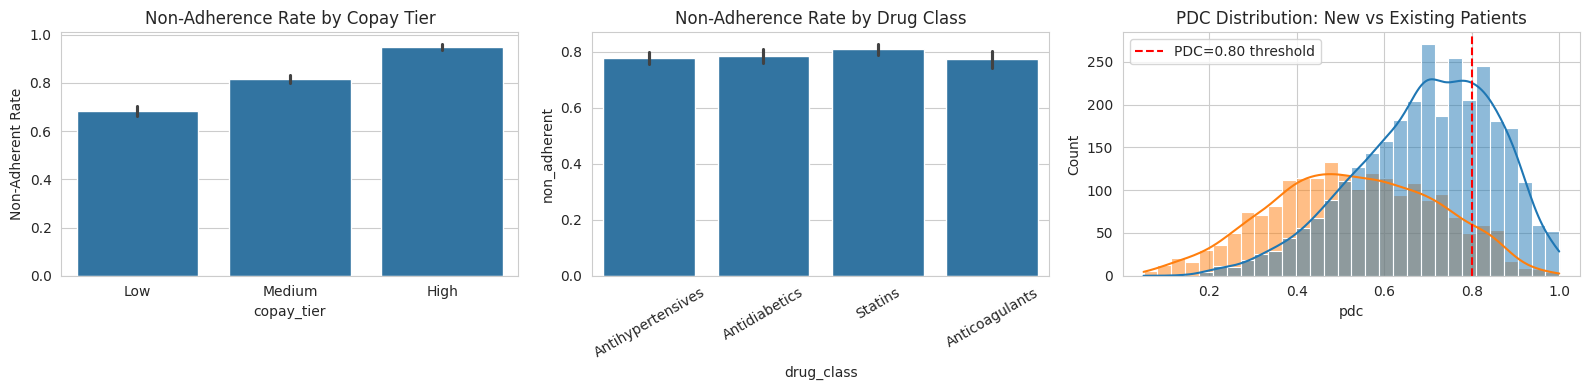

In [4]:
# CELL 4 — Visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=df, x='copay_tier', y='non_adherent', order=['Low','Medium','High'], ax=axes[0])
axes[0].set_title('Non-Adherence Rate by Copay Tier')
axes[0].set_ylabel('Non-Adherent Rate')

sns.barplot(data=df, x='drug_class', y='non_adherent', ax=axes[1])
axes[1].set_title('Non-Adherence Rate by Drug Class')
axes[1].tick_params(axis='x', rotation=30)

sns.histplot(data=df, x='pdc', hue='new_to_therapy', bins=30, kde=True, ax=axes[2])
axes[2].axvline(0.80, color='red', linestyle='--', label='PDC=0.80 threshold')
axes[2].set_title('PDC Distribution: New vs Existing Patients')
axes[2].legend()

plt.tight_layout()
plt.savefig('adherence_eda.png', dpi=150)
plt.show()

In [5]:
# CELL 5 — Logistic regression: predicting non-adherence
model_df = df.copy()
model_df['copay_medium'] = (model_df['copay_tier'] == 'Medium').astype(int)
model_df['copay_high'] = (model_df['copay_tier'] == 'High').astype(int)

formula = 'non_adherent ~ age + copay_medium + copay_high + mail_order + n_comorbidities + new_to_therapy'
logit_model = smf.logit(formula, data=model_df).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.380487
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           non_adherent   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4993
Method:                           MLE   Df Model:                            6
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                  0.2597
Time:                        09:05:28   Log-Likelihood:                -1902.4
converged:                       True   LL-Null:                       -2569.8
Covariance Type:            nonrobust   LLR p-value:                3.344e-285
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.1706      0.194     11.201      0.000       1.791       2.550
age           

In [6]:
# CELL 6 — Odds ratios (stakeholder-friendly presentation)
odds_ratios = np.exp(logit_model.params).round(3)
conf = np.exp(logit_model.conf_int())
conf.columns = ['OR_low', 'OR_high']
or_table = pd.concat([odds_ratios.rename('odds_ratio'), conf], axis=1)
print(or_table)

                 odds_ratio     OR_low    OR_high
Intercept             8.764   5.994309  12.812814
age                   0.961   0.955372   0.966859
copay_medium          2.417   2.042073   2.860283
copay_high           13.812  10.026141  19.026970
mail_order            0.243   0.205006   0.288633
n_comorbidities       1.739   1.609400   1.879077
new_to_therapy        7.207   5.891951   8.816633


In [7]:
# CELL 7 — Cohort analysis (region x risk cohort)
def risk_cohort(row):
    score = 0
    if row['copay_tier'] == 'High': score += 1
    if row['new_to_therapy'] == 1: score += 1
    if row['n_comorbidities'] >= 2: score += 1
    if row['mail_order'] == 0: score += 1
    return 'High Risk' if score >= 3 else ('Medium Risk' if score >= 1 else 'Low Risk')

df['risk_cohort'] = df.apply(risk_cohort, axis=1)

cohort_summary = df.groupby(['region', 'risk_cohort']).agg(
    patients=('patient_id', 'count'),
    avg_pdc=('pdc', 'mean'),
    non_adherent_rate=('non_adherent', 'mean')
).round(3).reset_index()

cohort_summary.sort_values(['region', 'risk_cohort'])

,region,risk_cohort,patients,avg_pdc,non_adherent_rate
0,Midwest,High Risk,206,0.444,0.981
1,Midwest,Low Risk,63,0.836,0.317
2,Midwest,Medium Risk,753,0.657,0.797
3,Northeast,High Risk,226,0.438,0.991
4,Northeast,Low Risk,69,0.814,0.406
5,Northeast,Medium Risk,835,0.658,0.777
6,Southeast,High Risk,165,0.437,0.982
7,Southeast,Low Risk,49,0.841,0.347
8,Southeast,Medium Risk,635,0.665,0.756
9,Southwest,High Risk,243,0.450,0.967


In [8]:
# CELL 8 — Export CSVs
df.to_csv('patient_adherence.csv', index=False)
cohort_summary.to_csv('cohort_summary.csv', index=False)
or_table.to_csv('logistic_regression_odds_ratios.csv')

from google.colab import files
files.download('patient_adherence.csv')
files.download('cohort_summary.csv')
files.download('logistic_regression_odds_ratios.csv')
print('Exported. Upload patient_adherence.csv to your GitHub repo under /data/.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exported. Upload patient_adherence.csv to your GitHub repo under /data/.
